In [76]:
import siibra
from nilearn import plotting, image
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
import plotly.graph_objects as go

import pyNN.neuron as sim
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator
import statistics
from pyNN.parameters import Sequence

# Julich Random Point Generator

In [2]:
#class to get random points based on the STN in the Julich Brain CYTOARCHITECTURE
#new with space to for leads
class Julich_brain_cyto_random_point_generator:
    def __init__(self,parcellation, region, space, stimulating_electrode_position, encapsulation):
        #obtain the brain region required
        self.region = siibra.get_region(parcellation, region)
        
        #get the space required
        self.space = self.region.spaces.get(space)

    
        self.region_map = self.region.get_regional_map(space, maptype="statistical")
        self.NIfTI_region = self.region_map.fetch()
        self.region_data = self.NIfTI_region.get_fdata()
        self.affine = self.NIfTI_region.affine
        print(self.affine)


        # Flatten and mask out zero or invalid voxels
        self.region_data_flat = self.region_data.flatten()
        self.region_data_valid_probs = self.region_data_flat[self.region_data_flat > 0]

        #normalise the probabilities to work with random choice
        self.region_data_valid_probs /= self.region_data_valid_probs.sum()  

        ## Get voxel indices (i,j,k) of valid voxels
        self.region_data_indices = np.argwhere(self.region_data > 0)

        #stimulating electrode position and encapsulation
        self.stimulating_electrode_position = stimulating_electrode_position
        self.encapsulation = encapsulation
      

     
    def sample_points_in_voxels(self, number_points):
        indices = np.random.choice(len(self.region_data_valid_probs), size = number_points, p=self.region_data_valid_probs)
        voxel_coords = self.region_data_indices[indices]

        offsets = np.random.normal(0, 0.33, size=(number_points, 3))
        voxel_points = voxel_coords + offsets

        ones = np.ones((number_points, 1))
        vox_hom = np.hstack([voxel_points, ones])          # (N,4)
        world_points = (self.affine @ vox_hom.T).T[:, :3]

        #remove points from the encapsulation layer
        x_min, x_max, y_min, y_max = self.stimulating_electrode_position[0]-self.encapsulation, self.stimulating_electrode_position[0]+self.encapsulation, self.stimulating_electrode_position[1]-self.encapsulation, self.stimulating_electrode_position[1]+self.encapsulation

                
        mask = ~(
        (x_min < world_points[:, 0]) & (world_points[:, 0] < x_max) &
        (y_min < world_points[:, 1]) & (world_points[:, 1] < y_max))
            

        if mask.sum() < number_points:
            # recursively fill remaining points
            missing = number_points - mask.sum()
            extra = self.sample_points_in_voxels(missing)
            world_points = np.vstack([world_points[mask], extra])
        else:
            world_points = world_points[mask][:number_points]
    
        return world_points

# Testing the Random Point Generator is working

In [3]:
parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1" 
region = "STN (Subthalamus) right"
space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"
stimulating_electrode = np.array([11600,-16200,-9100])/1000
encapsulation = 1.135


random_point_generator = Julich_brain_cyto_random_point_generator(parcellation,region,space, stimulating_electrode, encapsulation)

random_point_generator.sample_points_in_voxels(10)[:,0]

Loading preconfigured Map instances: 100%|████████████████████████████████████████████| 59/59 [00:00<00:00, 127.31Map/s]
[siibra:WARNING] Map registry contains multiple classes: SparseMap, Map


[[   1.    0.    0.  -96.]
 [   0.    1.    0. -132.]
 [   0.    0.    1.  -78.]
 [   0.    0.    0.    1.]]


array([11.56209502, 10.26906375, 11.03187818, 12.59151249, 13.53711783,
        8.92028435, 14.31181891, 11.44003462,  5.64143981,  7.87537613])

# Adding in the Voltages

### Boston Scientific 

In [27]:
voltage_file = pd.read_csv(
    "../2202_Mesh0_E1_270625_BSGrid_V.txt",
    sep=r"\s+",
    header=None,
    names=["x", "y", "z", "V"]
)

#translate the center to the center we have already identified
x_voltage_coordinates = voltage_file['x'].values+11.6
y_voltage_coordinates = voltage_file['y'].values-16.2
z_voltage_coordinates = voltage_file['z'].values-9.1

#convert to mV since NEURON and PyNN use mV
voltages = voltage_file['V'].values*1000

points = np.array([x_voltage_coordinates,y_voltage_coordinates,z_voltage_coordinates]).T

In [29]:
 Vint = LinearNDInterpolator(points, voltages)

### Caoimhe's Head Model

In [4]:
voltage_file = pd.read_csv(
    "../MDT3389_Mesh2_050126_E3_BSGrid.txt",
    sep=r"\s+",
    header=None,
    names=["x", "y", "z", "V"]
)

#translate the center to the center we have already identified
x_voltage_coordinates = voltage_file['x'].values+11.6
y_voltage_coordinates = voltage_file['y'].values-22.45
z_voltage_coordinates = voltage_file['z'].values-9.1

#convert to mV since NEURON and PyNN use mV
voltages = voltage_file['V'].values*1000

points = np.array([x_voltage_coordinates,y_voltage_coordinates,z_voltage_coordinates]).T

In [5]:
print(points)

[[  8.6        -22.45        -5.85      ]
 [  8.6        -21.95        -5.85      ]
 [  8.6        -21.45        -5.85      ]
 ...
 [ 14.44634416 -23.5159873    0.15      ]
 [ 14.19807621 -23.95         0.15      ]
 [ 14.44807621 -23.5169873    0.15      ]]


In [6]:
 Vint = LinearNDInterpolator(points, voltages)

# Simple Neuron with extracellular implemented

In [5]:
from nrnutils import Mechanism, Section

class SimpleNeuron(object):

    def __init__(self, **parameters):
        hh = Mechanism('hh', gl=parameters['g_leak'], el=-65, gnabar=parameters['gnabar'], gkbar=parameters['gkbar'])
        self.soma = Section(L=30, diam=30, mechanisms=[hh])
        self.soma.add_synapse('ampa', 'Exp2Syn', e=0.0, tau1=0.1, tau2=5.0)
        self.initial_values = {"v": -65.0}

        self.soma.insert("extracellular")

        # needed for PyNN
        self.source_section = self.soma
        self.source = self.soma(0.5)._ref_v
        self.parameter_names = ('g_leak', 'gnabar', 'gkbar')
        self.traces = {}
        self.recording_time = False

In [6]:
from pyNN.neuron import NativeCellType

class SimpleNeuronType(NativeCellType):
    default_parameters = {'g_leak': 0.0002, 'gkbar': 0.036, 'gnabar': 0.12}
    default_initial_values = {'v': -65.0}
    recordable = ['soma(0.5).v', 'soma(0.5).ina']
    units = {'soma(0.5).v' : 'mV', 'soma(0.5).ina': 'nA'}
    receptor_types = ['soma.ampa']
    model = SimpleNeuron

# Create the Neurons

In [9]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
import pyNN.neuron as sim
import matplotlib.pyplot as plt
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
import numpy as np
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

v_init = -68
rng_seed = 856
n = 100
parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1" 
region = "STN (Subthalamus) right"
space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"
stimulating_electrode = np.array([11600,-16200,-9100])/1000
encapsulation = 1.135


############ Setup the simulation##########
sim.setup(timestep=0.01)

########## create a population of neurons ###############
cortical_pop = sim.Population(n, SimpleNeuronType())


random_point_generator = Julich_brain_cyto_random_point_generator(parcellation,region,space, stimulating_electrode, encapsulation)
STN_space = random_point_generator.sample_points_in_voxels(n)
cortical_pop.positions[0], cortical_pop.positions[1],cortical_pop.positions[2] = STN_space[:,0], STN_space[:,1], STN_space[:,2]

[[   1.    0.    0.  -96.]
 [   0.    1.    0. -132.]
 [   0.    0.    1.  -78.]
 [   0.    0.    0.    1.]]


In [10]:
print(min(cortical_pop.positions[2]), max(cortical_pop.positions[2]))
print(statistics.stdev(cortical_pop.positions[1]))

-16.07326609855467 -5.46483316512861
2.641858381810447


# Add the voltages to the positions

In [11]:
x_points_ctx = cortical_pop.positions[0]
y_points_ctx = cortical_pop.positions[1]
z_points_ctx = cortical_pop.positions[2]
interpolated_values_ctx = Vint(np.column_stack((x_points_ctx, y_points_ctx, z_points_ctx)))
efield = np.column_stack((x_points_ctx, y_points_ctx, z_points_ctx,interpolated_values_ctx))

In [96]:
print(efield)

[[ 12.84020681 -13.51593577 -11.04583268          nan]
 [  8.47048398 -13.17214827  -7.58109857          nan]
 [ 14.96833686 -15.05715935  -8.27570327          nan]
 [  8.28008847  -7.98639034  -9.20819625          nan]
 [ 13.2730641  -16.91961517 -11.42921438          nan]
 [  9.74080441 -17.29682042  -9.55176523          nan]
 [  7.02507366 -16.86058735 -12.90578722          nan]
 [ 13.42565114 -15.86098595 -11.01340389          nan]
 [ 10.74064365  -9.89812443  -8.05168815          nan]
 [ 12.9423749  -14.34482531 -11.92365483          nan]
 [ 15.65794282 -13.92019466  -9.14596444          nan]
 [ 10.19439616 -16.97369145  -9.79751039          nan]
 [ 14.2785736  -14.79757927 -11.05248813          nan]
 [ 12.84585768 -15.66751116 -10.15524376          nan]
 [  9.66422847 -18.78603278 -13.9392174           nan]
 [ 13.27115196 -13.33745013  -8.8665991           nan]
 [  8.15128373 -17.95938007 -12.89446589          nan]
 [  8.4472013  -15.61766637 -16.75586702          nan]
 [  7.8269

# Test that it works

In [12]:
for cell in cortical_pop:
    test = (cell.position == efield[:, :-1])
    indices = np.where(np.all(test, axis=1))[0]
    indices = int(indices[0])
    cell.e_extracellular = efield[indices, 3]
    print(cell, cell.position, indices, cell.e_extracellular)

0 [  9.04504633 -19.84493915 -11.62651031] 0 nan
1 [  9.67835329 -18.15841521 -13.16507987] 1 nan
2 [  6.2647915  -12.41036461 -15.26644876] 2 nan
3 [ 10.51845607 -13.8420141  -12.85538861] 3 nan
4 [  7.62008955 -10.6706775   -8.22665099] 4 nan
5 [ 13.63904044 -13.66822721 -11.34758479] 5 nan
6 [ 13.44586241 -14.60804974 -11.00894292] 6 nan
7 [ 10.50416942 -13.15927045 -10.35607177] 7 nan
8 [ 10.90766608 -13.54027925 -11.94047837] 8 nan
9 [ 10.1963468  -14.02305692  -8.56337267] 9 nan
10 [  9.57208554 -12.76957462  -9.48746997] 10 nan
11 [  6.43100254 -13.40183571 -13.24238127] 11 nan
12 [ 11.48830043 -17.99879893 -11.13432809] 12 nan
13 [ 14.22312974 -17.53012743  -8.89352492] 13 nan
14 [  9.7481163  -17.83641915  -8.14405512] 14 nan
15 [ 14.86434863 -10.4897743   -9.05986224] 15 nan
16 [ 11.03798003 -12.97248367 -13.41826031] 16 nan
17 [  9.12027142 -13.8727128  -13.8165989 ] 17 nan
18 [  9.1097381  -12.87452241  -8.59851204] 18 nan
19 [  9.157855   -15.67376728 -10.90541715] 19 nan


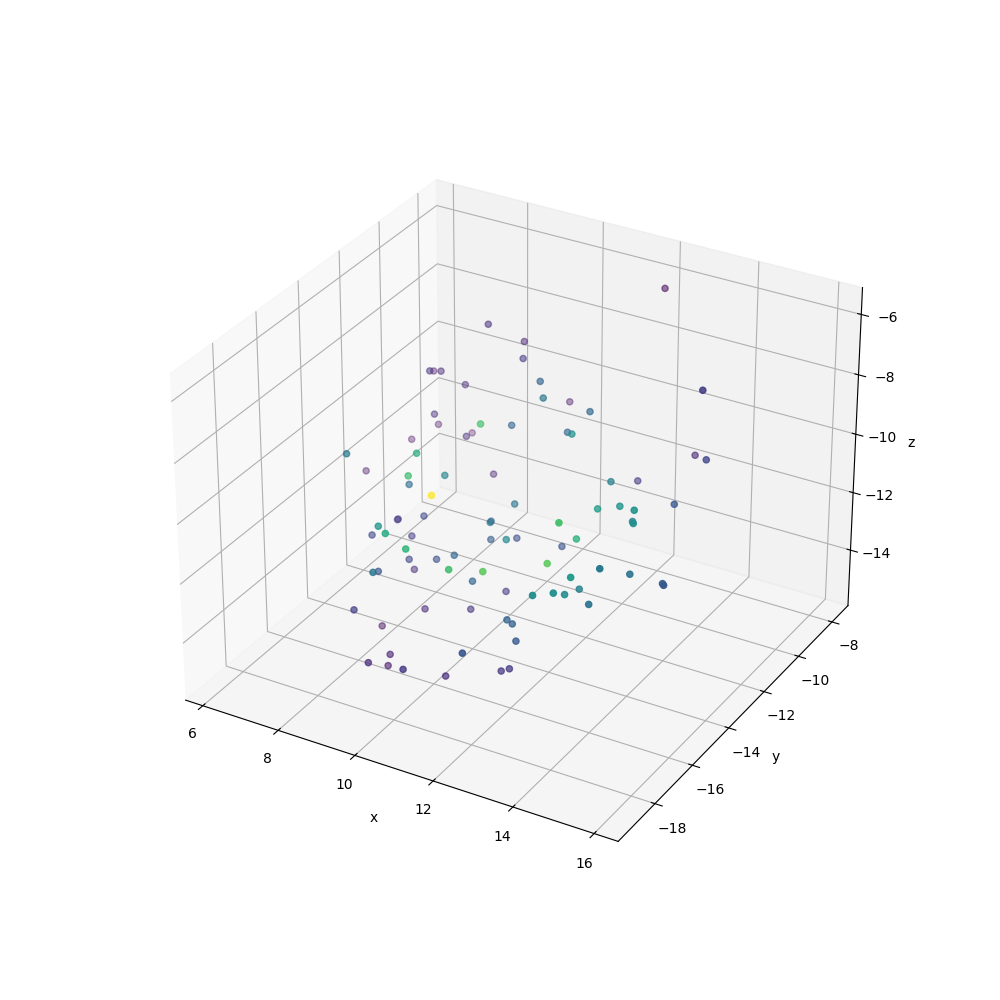

In [47]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('x')
ax.set_zlabel('z')
ax.set_ylabel('y')

#interpolate the values for the ctx neurons
x_points_ctx = cortical_pop.positions[0]
y_points_ctx = cortical_pop.positions[1]
z_points_ctx = cortical_pop.positions[2]
ax.scatter(x_points_ctx, y_points_ctx, z_points_ctx, c=interpolated_values_ctx)

#legend1 = ax.legend(*scatter.legend_elements(), loc="upper right", title="Voltage V")
#ax.add_artist(legend1)
plt.show()

# 20260108 - using the sphere shape and see does that work with the head model

#### Adding in the sphere shape

In [2]:
class Sphere():
    def __init__(self, radius):
        self.radius = radius
                
    def generate_positions(self, n):
        """Return `n` points distributed randomly with uniform density within the sphere with encapsulation layer"""
        num_points = n
        
        x_points = [] 
        y_points = [] 
        z_points = [] 
        
        theta = np.random.uniform(0, 2 * np.pi, num_points) 
        phi = np.random.uniform(0, np.pi, num_points) 
        x_radius = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))  
        y_radius = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))
        z_radius = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))
            
        x_points = x_radius * np.sin(phi) * np.cos(theta)
        y_points = y_radius * np.sin(phi) * np.sin(theta) 
        z_points = z_radius * np.cos(phi)

                   
        for idy, j in enumerate(y_points):
            invalid_y = (-1500 < j) and (j < 2000)
            while invalid_y:
                theta = np.random.uniform(0, 2 * np.pi) 
                phi = np.random.uniform(0, np.pi) 
                y_radius = 2000*np.cbrt(np.random.uniform(0, 1))
                j = y_radius * np.sin(phi) * np.sin(theta) 
                invalid_y = (-1500 < j) and (j < 2000)
            y_points[idy] = j


        for idx, i in enumerate(x_points):
            invalid_x = (-500 < i) and (i < 500)
            while invalid_x:
                theta = np.random.uniform(0, 2 * np.pi) 
                phi = np.random.uniform(0, np.pi) 
                x_radius = 2000*np.cbrt(np.random.uniform(0, 1))
                i = x_radius * np.sin(phi) * np.cos(theta) 
                invalid_x = (-500 < i) and (i < 500)
            x_points[idx] = i

        return x_points, y_points, z_points

In [19]:
class Sphere2():
    def __init__(self, radius):
        self.radius = radius
                
    def generate_positions(self, n):
        """Return `n` points distributed randomly with uniform density within the sphere with encapsulation layer"""
        num_points = n
        
        x_points = [] 
        y_points = [] 
        z_points = [] 
        
        theta = np.random.uniform(0, 2 * np.pi, num_points) 
        phi = np.random.uniform(0, np.pi, num_points) 
        x_radius = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))  
        y_radius = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))
        z_radius = self.radius*np.cbrt(np.random.uniform(0, 1, num_points))
            
        x_points = x_radius * np.sin(phi) * np.cos(theta)
        y_points = y_radius * np.sin(phi) * np.sin(theta) 
        z_points = z_radius * np.cos(phi)

        invalid_x = (x_points > -500) & (x_points < 500)
        invalid_y = (y_points > -1500) & (y_points < 2000)
        
        invalid = invalid_x & invalid_y

        while np.any(invalid):
            n = invalid.sum()

            # Sample spherical distribution
            theta = np.random.uniform(0, 2*np.pi, n)
            phi   = np.random.uniform(0, np.pi, n)
            r     = 2000 * np.cbrt(np.random.uniform(0, 1, n))

            # Compute new x and y for all invalid points at once
            new_x = r * np.sin(phi) * np.cos(theta)
            new_y = r * np.sin(phi) * np.sin(theta)

            # Assign
            x_points[invalid] = new_x
            y_points[invalid] = new_y

            # Recompute masks
            invalid_x = (x_points > -500) & (x_points < 500)
            invalid_y = (y_points > -1500) & (y_points < 2000)
            invalid = invalid_x & invalid_y

        points = np.column_stack((x_points, y_points, z_points))

            
        return points

In [3]:
ellipse = Sphere(2000)
STN_space = ellipse.generate_positions(100)

In [21]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
import pyNN.neuron as sim
import matplotlib.pyplot as plt
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
import numpy as np
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

v_init = -68
rng_seed = 856
n = 100
parcellation = "JULICH_BRAIN_CYTOARCHITECTONIC_ATLAS_V3_1" 
region = "STN (Subthalamus) right"
space = "MNI_152_ICBM_2009C_NONLINEAR_ASYMMETRIC"
stimulating_electrode = np.array([11600,-16200,-9100])/1000
encapsulation = 1.135


############ Setup the simulation##########
sim.setup(timestep=0.01)

########## create a population of neurons ###############
cortical_pop = sim.Population(n, SimpleNeuronType())

ellipse = Sphere2(2000)
cortical_space = ellipse.generate_positions(n)
cortical_pop.positions[0], cortical_pop.positions[1],cortical_pop.positions[2] = cortical_space[:,0], cortical_space[:,1], cortical_space[:,2]

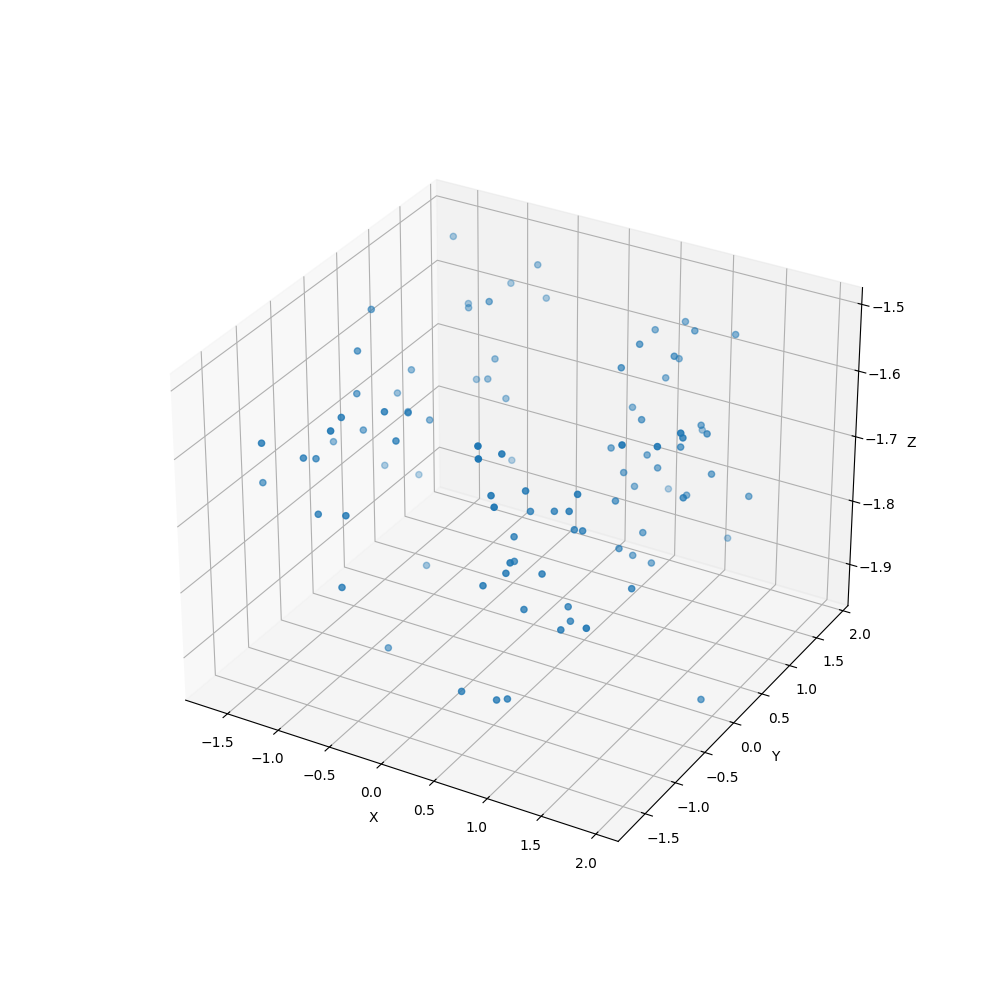

In [8]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

#interpolate the values for the ctx neurons
x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]
ax.scatter(x_points_clean_ctx, z_points_clean_ctx, y_points_clean_ctx)



plt.show()

In [14]:
voltage_file = pd.read_csv(
    "../MDT3389_Mesh2_050126_E3_BSGrid.txt",
    sep=r"\s+",
    header=None,
    names=["x", "y", "z", "V"]
)

#translate the center to the center we have already identified - no need to translate the sphere since it is already centered at (0,0,0)
x_voltage_coordinates = voltage_file['x'].values*1000
y_voltage_coordinates = voltage_file['y'].values*1000
z_voltage_coordinates = voltage_file['z'].values*1000-6250

#convert to mV since NEURON and PyNN use mV
voltages = voltage_file['V'].values*1000

points = np.array([x_voltage_coordinates,y_voltage_coordinates,z_voltage_coordinates]).T

In [15]:
 Vint = LinearNDInterpolator(points, voltages)

In [107]:
x_points_ctx = cortical_pop.positions[0]
y_points_ctx = cortical_pop.positions[1]
z_points_ctx = cortical_pop.positions[2]
interpolated_values_ctx = Vint(np.column_stack((x_points_ctx, y_points_ctx, z_points_ctx)))
efield = np.column_stack((x_points_ctx, y_points_ctx, z_points_ctx,interpolated_values_ctx))

In [93]:
for ii, cell in enumerate(cortical_pop):
    cell.e_extracellular = interpolated_values_ctx[ii]


In [142]:
#interpolated_values_ctx = [[item] for item in interpolated_values_ctx]
test = [np.repeat(item, 11, axis=0) for item in interpolated_values_ctx ]
test = np.array(test)
print(test[12][3])

787.8324142282851


In [106]:
print(test[1, 1])

IndexError: index 1 is out of bounds for axis 1 with size 1

In [68]:
for cell in cortical_pop:
    test = (cell.position == efield[:, :-1])
    indices = np.where(np.all(test, axis=1))[0]
    indices = int(indices[0])
    cell.e_extracellular = efield[indices, 3]
    print(cell, cell.position, indices, cell.e_extracellular)

0 [1687.31870329 -126.64710003 -194.5897321 ] 0 766.1449611156766
1 [-639.69610556 -531.94551642 1416.42379151] 1 744.8667513848085
2 [  509.37693476  -303.52825014 -1010.43259249] 2 812.7586427517122
3 [ -965.21707332 -1152.26097225   722.58046211] 3 772.513472529167
4 [-1013.49290498   533.91506699  1187.36616323] 4 768.606296307961
5 [-1081.3542012   1324.18120972   -34.80009341] 5 768.1239223764879
6 [ 798.50461781   23.49228848 1020.10359222] 6 812.3604173540996
7 [ -629.90045355 -1393.52248063 -1788.52133652] 7 693.2065897022401
8 [ -733.03231115   225.36862226 -1818.12190414] 8 707.7711481720492
9 [-1641.98596521   470.0986347  -1717.8227557 ] 9 690.2344950480261
10 [1696.67696725  716.23254224  -37.94680658] 10 749.9649514859295
11 [ 850.76444165 1430.53589956  -50.85854854] 11 774.1934382028106
12 [-1386.2959279    453.7504161    612.68433098] 12 787.8324142282851
13 [652.42023694 992.46065435 858.68212638] 13 807.3483193681807
14 [  673.98196092   431.64098304 -1661.3651085 ]